# Hypergraphx-data interface

Load datasets from the Hypergraphx-data repository using the remote catalog.

## Overview

- Search and inspect datasets without downloading them.
- Load `pokemon-moves` as a standard static hypergraph.
- Select temporal datasets from the catalog.
- Iterate over multiple cooking datasets without storing downloaded files.

## Setup

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt

import hypergraphx as hgx

mpl.rcParams.update({
    "figure.figsize": (6, 4),
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "normal",
    "axes.labelsize": 9,
    "axes.titlesize": 11,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

In [2]:
def dataset_summary_row(H, info):
    return {"name": info["name"], **H.summary(max_size_bins=10)}


def print_dataset_summary(H, info):
    for key, value in dataset_summary_row(H, info).items():
        print(f"{key}: {value}")


def polish_axes(axes):
    for ax in axes:
        ax.tick_params(axis="both", which="both", length=0)
        ax.margins(x=0.04, y=0.08)

## Load a static dataset

Use the catalog to inspect the dataset before loading it.

In [3]:
info = hgx.get_remote_dataset_info("pokemon-moves")

print(info["name"])
print(info.get("description"))
print(info.get("license"))
print(info.get("tags"))

pokemon-moves
None
None
['Undirected', 'Biology', 'Games']


In [4]:
H = hgx.load_hypergraph_from_server("pokemon-moves", store=False)

print_dataset_summary(H, info)

name: pokemon-moves
type: Hypergraph
weighted: False
num_nodes: 1328
num_edges: 811
uniform: False
min_size: 1
max_size: 1246
size_bins: 279


In [5]:
list(H.get_edges())[:5]

[(235,), (249,), (385,), (416,), (441,)]

## Analyze Pokémon moves

In `pokemon-moves`, each node is a Pokémon and each hyperedge is a group of Pokémon that can learn the same move. Some moves have exactly the same set of Pokémon and are stored as one collapsed hyperedge; their names are listed in the hyperedge metadata.

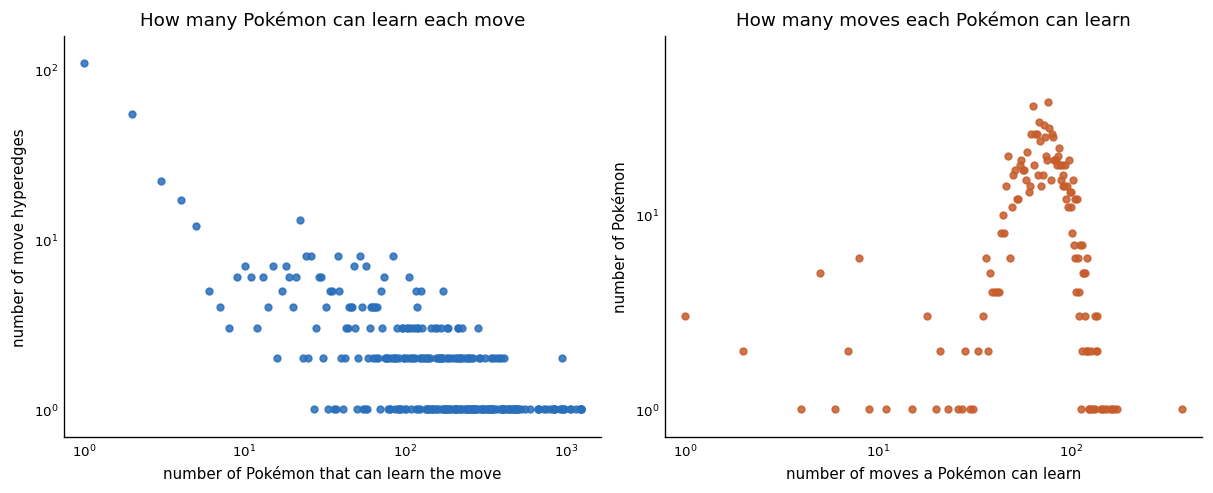

In [6]:
size_distribution = H.distribution_sizes()
degree_distribution = H.degree_distribution()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

sizes, size_counts = zip(*sorted(size_distribution.items()))
axes[0].loglog(sizes, size_counts, "o", color="#2a6fbb", markersize=4, alpha=0.85)
axes[0].set_xlabel("number of Pokémon that can learn the move")
axes[0].set_ylabel("number of move hyperedges")
axes[0].set_title("How many Pokémon can learn each move")

degrees, degree_counts = zip(*sorted(degree_distribution.items()))
axes[1].loglog(degrees, degree_counts, "o", color="#c75d2c", markersize=4, alpha=0.85)
axes[1].set_xlabel("number of moves a Pokémon can learn")
axes[1].set_ylabel("number of Pokémon")
axes[1].set_title("How many moves each Pokémon can learn")

polish_axes(axes)

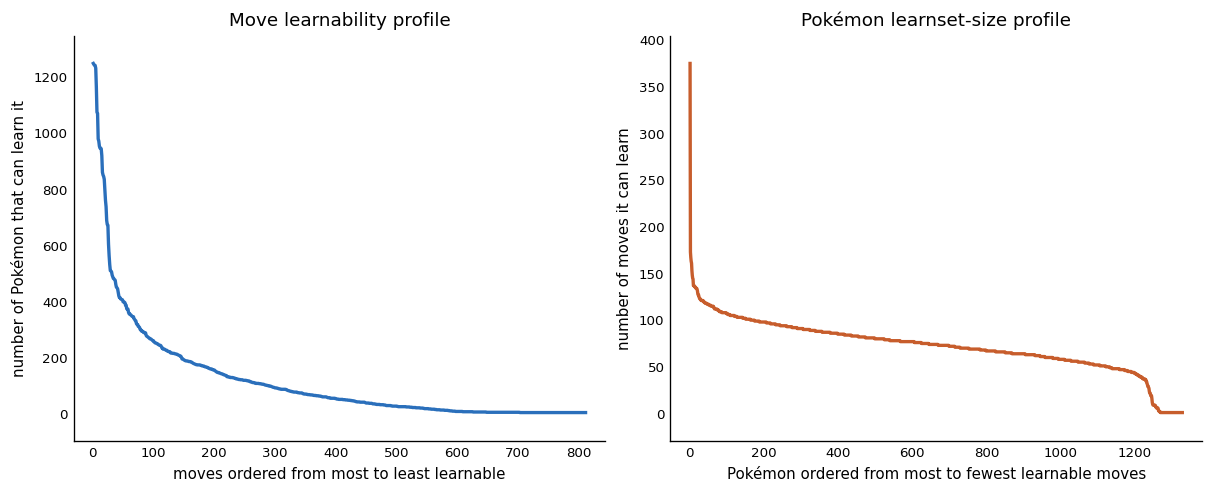

In [7]:
# Rank 1 is the largest value in each plot.
edge_sizes = sorted(H.get_sizes(), reverse=True)
node_degrees = sorted(H.degree_sequence().values(), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

axes[0].plot(range(1, len(edge_sizes) + 1), edge_sizes, color="#2a6fbb", linewidth=2)
axes[0].set_xlabel("moves ordered from most to least learnable")
axes[0].set_ylabel("number of Pokémon that can learn it")
axes[0].set_title("Move learnability profile")

axes[1].plot(range(1, len(node_degrees) + 1), node_degrees, color="#c75d2c", linewidth=2)
axes[1].set_xlabel("Pokémon ordered from most to fewest learnable moves")
axes[1].set_ylabel("number of moves it can learn")
axes[1].set_title("Pokémon learnset-size profile")

polish_axes(axes)

In [8]:
def pokemon_name(node):
    return H.get_node_metadata(node).get("name", node)


def move_names(edge):
    return H.get_edge_metadata(edge).get("move_names", [])


top_pokemon = sorted(
    H.degree_sequence().items(),
    key=lambda item: item[1],
    reverse=True,
)[:5]

top_moves = sorted(H.get_edges(), key=len, reverse=True)[:5]

rare_moves = sorted(H.get_edges(), key=lambda edge: (len(edge), move_names(edge)))[:5]

print("Top 5 Pokémon by number of learnable moves")
for node, degree in top_pokemon:
    print(f"{pokemon_name(node)}: {degree}")

print("\nTop 5 move hyperedges by number of Pokémon")
for edge in top_moves:
    print(f"{', '.join(move_names(edge))}: {len(edge)} Pokémon")

print("\nRare move examples")
for edge in rare_moves:
    example = pokemon_name(edge[0])
    print(f"{', '.join(move_names(edge))}: {len(edge)} Pokémon; example: {example}")

Top 5 Pokémon by number of learnable moves
mew: 374
arceus: 172
mewtwo: 166
clefable: 162
clefairy: 160

Top 5 move hyperedges by number of Pokémon
protect: 1246 Pokémon
substitute: 1242 Pokémon
rest: 1240 Pokémon
sleep-talk: 1239 Pokémon
facade: 1229 Pokémon

Rare move examples
aeroblast: 1 Pokémon; example: lugia
anchor-shot: 1 Pokémon; example: dhelmise
apple-acid: 1 Pokémon; example: appletun
aqua-step: 1 Pokémon; example: quaquaval
armor-cannon: 1 Pokémon; example: armarouge


## Select temporal datasets

Catalog filters can be combined before downloading any dataset.

In [9]:
temporal_datasets = hgx.search_remote_datasets(tags=["Temporal"])

[(d["name"], d.get("vertices"), d.get("edges")) for d in temporal_datasets[:10]]

[('DAWN', 2558, 2272433),
 ('Elem1', 339, 226323),
 ('Mid1', 591, 518191),
 ('NDC-classes', 1161, 19160),
 ('NDC-substances', 5556, 112919),
 ('coauth-DBLP', 1930378, 3700681),
 ('coauth-geology', 1261129, 1591166),
 ('coauth-history', 1034876, 1813147),
 ('congress-bills', 1718, 282049),
 ('contacts-conference-hypertext', 113, 19037)]

In [10]:
small_temporal = hgx.search_remote_datasets(
    tags=["Temporal"],
    max_nodes=1000,
    max_edges=10000,
)

[(d["name"], d.get("vertices"), d.get("edges")) for d in small_temporal]

[('contacts-workplace', 92, 9645)]

In [11]:
temporal_names = [d["name"] for d in small_temporal[:3]]

for H, info in hgx.iter_remote_hypergraphs(
    names=temporal_names,
    include_metadata=True,
    store=False,
):
    print_dataset_summary(H, info)
    print()

name: contacts-workplace
type: TemporalHypergraph
weighted: False
num_nodes: 92
num_edges: 9645
uniform: False
size_distribution: {2: 9555, 3: 88, 4: 2}
num_times: 7104
min_time: 0
max_time: 987620



## Select multiple cooking datasets

Use explicit names when you want a fixed collection.

In [12]:
cooking_names = [
    "cooking-italian",
    "cooking-french",
    "cooking-indian",
    "cooking-japanese",
]

cooking_info = [hgx.get_remote_dataset_info(name) for name in cooking_names]

[(d["name"], d.get("vertices"), d.get("edges")) for d in cooking_info]

[('cooking-italian', 2929, 7758),
 ('cooking-french', 2102, 2609),
 ('cooking-indian', 1664, 2980),
 ('cooking-japanese', 1439, 1387)]

## Iterate over multiple datasets

The iterator loads datasets lazily. With `include_metadata=True`, each hypergraph is returned together with its catalog entry.

In [13]:
rows = []

for H, info in hgx.iter_remote_hypergraphs(
    names=cooking_names,
    include_metadata=True,
    store=False,
):
    rows.append(dataset_summary_row(H, info))

rows

[{'name': 'cooking-italian',
  'type': 'Hypergraph',
  'weighted': False,
  'num_nodes': 2929,
  'num_edges': 7758,
  'uniform': False,
  'min_size': 1,
  'max_size': 65,
  'size_bins': 31},
 {'name': 'cooking-french',
  'type': 'Hypergraph',
  'weighted': False,
  'num_nodes': 2102,
  'num_edges': 2609,
  'uniform': False,
  'min_size': 1,
  'max_size': 31,
  'size_bins': 29},
 {'name': 'cooking-indian',
  'type': 'Hypergraph',
  'weighted': False,
  'num_nodes': 1664,
  'num_edges': 2980,
  'uniform': False,
  'min_size': 1,
  'max_size': 49,
  'size_bins': 34},
 {'name': 'cooking-japanese',
  'type': 'Hypergraph',
  'weighted': False,
  'num_nodes': 1439,
  'num_edges': 1387,
  'uniform': False,
  'min_size': 1,
  'max_size': 34,
  'size_bins': 28}]